Импорт библиотек и загрузка данных

Несжатая карта A: 1180 x 884
Исходный кадр B:  878 x 884
Сжатый кадр B:    153 x 154


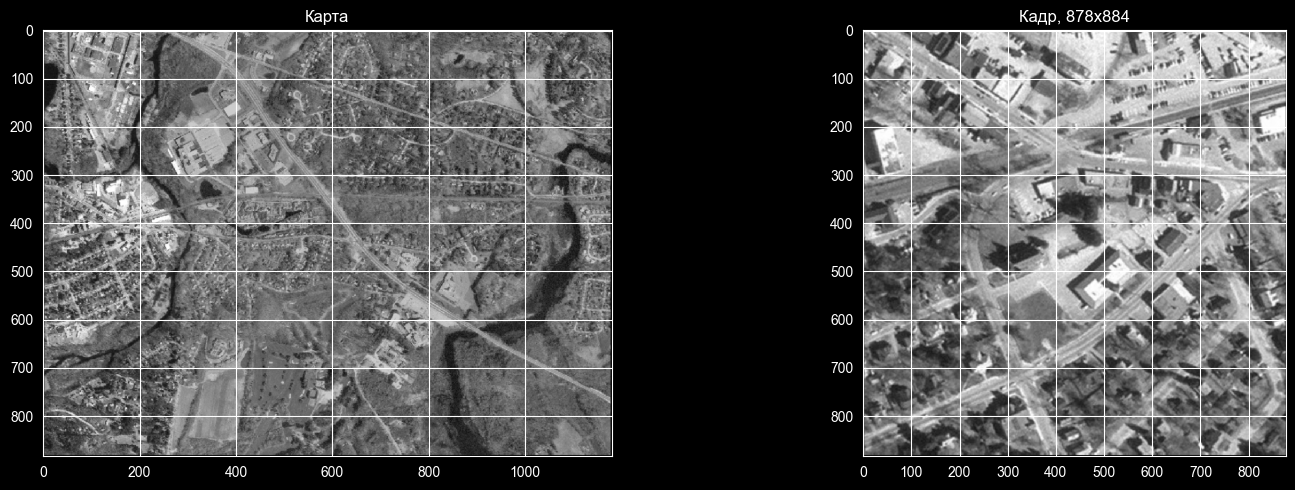

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import time
from scipy.ndimage import rotate
from tqdm import tqdm

%matplotlib inline

# Загрузка изображений
A = cv2.imread('ConcordOrthoPhoto.png', cv2.IMREAD_GRAYSCALE)
B = cv2.imread('WestConcordOrthoPhoto.png', cv2.IMREAD_GRAYSCALE)

if A is None or B is None:
    raise FileNotFoundError("Файлы не найдены. Проверьте наличие изображений в папке.")

A = A.astype(np.float64)
B = B.astype(np.float64)

h, w = A.shape
h1_full, w1_full = B.shape

print(f"Несжатая карта A: {w} x {h}")
print(f"Исходный кадр B:  {w1_full} x {h1_full}")

# Сжимаем ТОЛЬКО кадр в 5.75 раз
SCALE = 5.75

B_small = cv2.resize(B, None, fx=1 / SCALE, fy=1 / SCALE, interpolation=cv2.INTER_AREA)

# h1, w1 = B_small.shape
# print(f"Сжатый кадр B:    {w1} x {h1}")

# Проверка
# if h1 > h or w1 > w:
#     raise ValueError("Сжатый кадр больше карты. Проверьте изображения.")

# Отображение
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(A, cmap='gray')
axes[0].set_title('Карта')

axes[1].imshow(B, cmap='gray')
axes[1].set_title(f'Кадр, {w1_full}x{h1_full}')

# axes[2].imshow(B_small, cmap='gray')
# axes[2].set_title(f'Сжатый кадр B_small, {w1}x{h1}')

plt.tight_layout()
plt.show()

def show_result(A, B_small, R, method_name):
    """
    Ищет максимум корреляционной функции и показывает:
    1) корреляционную функцию;
    2) несжатую карту A с рамкой найденного сжатого кадра.
    """

    h, w = A.shape
    h1, w1 = B_small.shape

    # Ограничиваем поиск только допустимыми положениями кадра на карте
    R_valid = R[:h - h1 + 1, :w - w1 + 1]

    y, x = np.unravel_index(np.argmax(R_valid), R_valid.shape)
    Rmax = R_valid[y, x]

    print(f"[{method_name}]")
    print(f"Найден максимум: x = {x}, y = {y}, Rmax = {Rmax:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Корреляционная функция
    axes[0].imshow(-R_valid, cmap='gray')
    axes[0].plot(x, y, 'r+', markersize=12, markeredgewidth=2)
    axes[0].set_title(f'{method_name}: максимум в точке ({x}, {y})')

    # карта с найденной областью
    axes[1].imshow(A, cmap='gray')
    rect = patches.Rectangle((x, y), w1, h1, linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].set_title(f'Найденный кадр на карте: ({x}, {y})')
    plt.tight_layout()
    plt.show()

    return x, y

1. Прямой метод расчета корреляционной функции.

100%|██████████| 1028/1028 [00:16<00:00, 62.03it/s]



Время расчета для 1028 позиций по x: 16.58 сек
[Прямой метод]
Найден максимум: x = 77, y = 308, Rmax = 506605691.2792


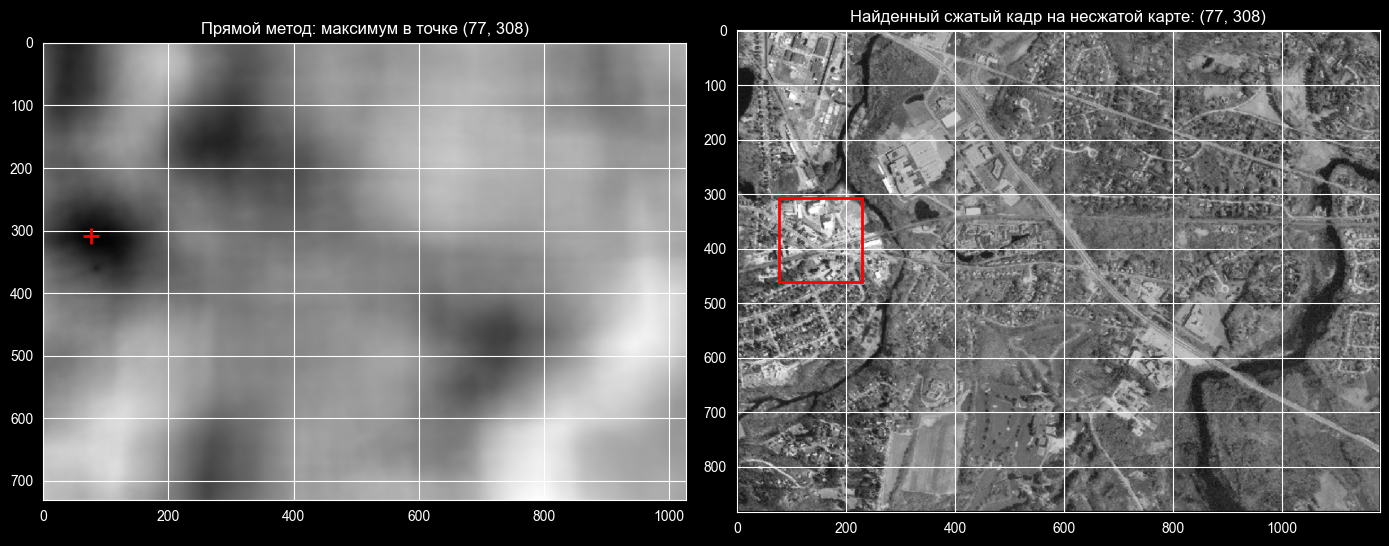

(np.int64(77), np.int64(308))

In [2]:
# Если хотите полный расчет, поставьте DIRECT_FULL = True
DIRECT_FULL = True

h, w = A.shape
h1, w1 = B_small.shape

# Область допустимых положений
valid_h = h - h1 + 1
valid_w = w - w1 + 1

if DIRECT_FULL:
    x_max_calc = valid_w
else:
    # Ограничимся первыми 200 положениями по x для демонстрации
    x_max_calc = min(200, valid_w)

R_direct = np.zeros((valid_h, x_max_calc), dtype=np.float64)

t0 = time.time()

for x in tqdm(range(x_max_calc)):
    # if x % 20 == 0:
    #     print(f"x = {x}")

    for y in range(valid_h):
        R_direct[y, x] = np.sum(A[y:y + h1, x:x + w1] * B_small)

dt = time.time() - t0

print(f"\nВремя расчета для {x_max_calc} позиций по x: {dt:.2f} сек")

if not DIRECT_FULL:
    print("Выполнен неполный прямой расчет.")
    print("Для полного расчета поставьте DIRECT_FULL = True")

# Отображение результата
R_show = np.zeros((valid_h, valid_w), dtype=np.float64)
R_show[:, :x_max_calc] = R_direct

show_result(A, B_small, R_show, "Прямой метод")

2. Спектральный расчет корреляции.

Время спектрального расчета: 0.1460 сек
[Спектральная корреляция]
Найден максимум: x = 77, y = 308, Rmax = 506605691.2792


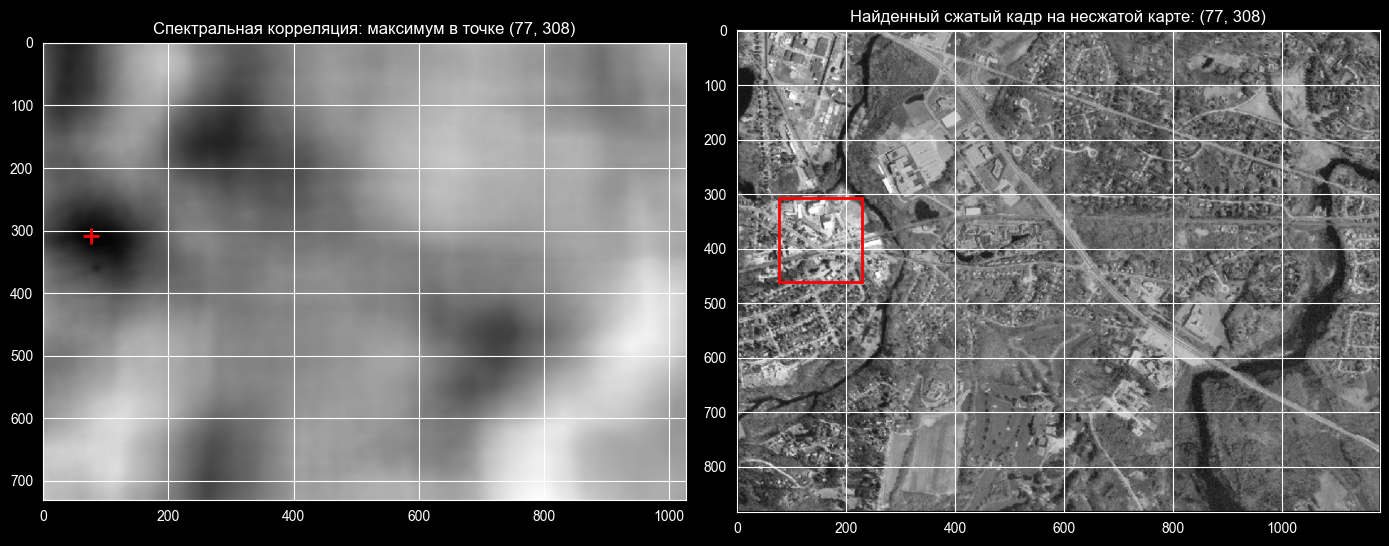

(np.int64(77), np.int64(308))

In [3]:
def FindCorr(A, B):
    """
    Спектральная корреляция:
    R = F^-1[F(A) * conj(F(B))]
    """

    h, w = A.shape

    Sa = np.fft.fft2(A)
    Sb = np.fft.fft2(B, s=(h, w))

    Sr = Sa * np.conj(Sb)

    R = np.fft.ifft2(Sr)

    return np.real(R)


t0 = time.time()
R_spectral = FindCorr(A, B_small)
dt = time.time() - t0

print(f"Время спектрального расчета: {dt:.4f} сек")

show_result(A, B_small, R_spectral, "Спектральная корреляция")

3. Фазовая корреляция.

[Фазовая корреляция]
Найден максимум: x = 83, y = 360, Rmax = 0.0098


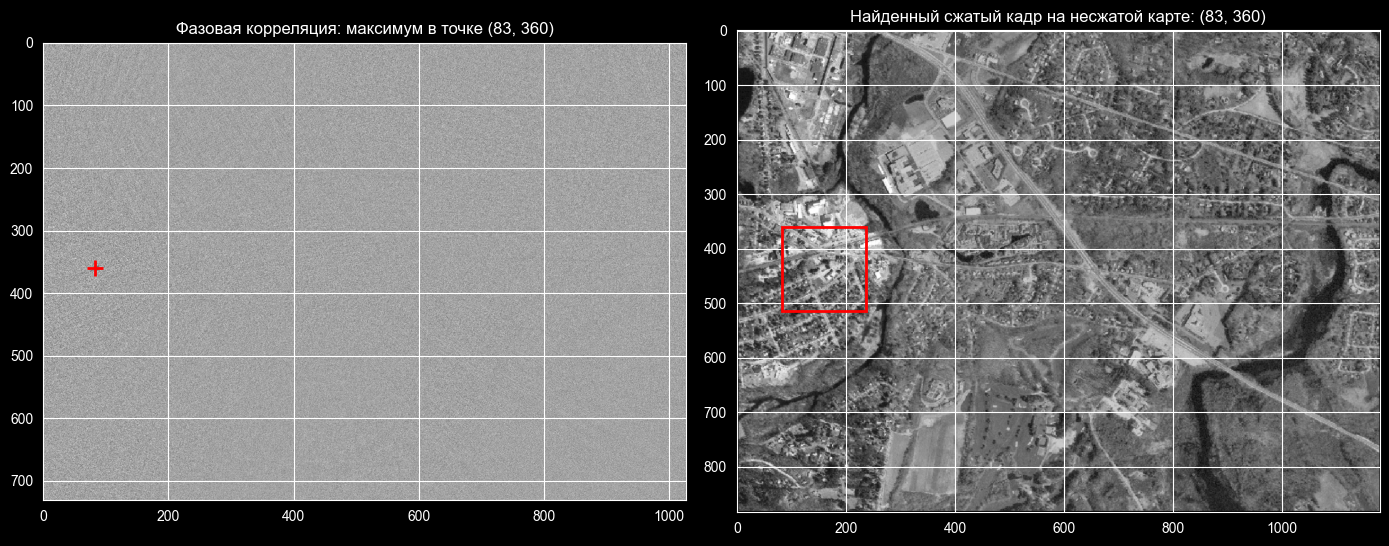

Проверка фазовой корреляции при изменении яркости сжатого кадра
delta = -100, найденный пик: x = 83, y = 360
delta =  -50, найденный пик: x = 83, y = 360
delta =  -20, найденный пик: x = 83, y = 360
delta =  +20, найденный пик: x = 83, y = 360
delta =  +50, найденный пик: x = 83, y = 360
delta = +100, найденный пик: x = 83, y = 360


In [4]:
def PhaseCorr(A, B):
    """
    Фазовая корреляция:
    оставляем только фазу спектра
    """
    h, w = A.shape
    Sa = np.fft.fft2(A)
    Sb = np.fft.fft2(B, s=(h, w))
    Sr = Sa * np.conj(Sb)
    # Удаляем амплитуду
    Sr = Sr / (np.abs(Sr) + 1e-10)
    R = np.fft.ifft2(Sr)
    return np.real(R)

R_phase = PhaseCorr(A, B_small)
show_result(A, B_small, R_phase, "Фазовая корреляция")

print("Проверка фазовой корреляции при изменении яркости сжатого кадра")

for delta in [-100, -50, -20, 20, 50, 100]:
    B_test = B_small + delta
    R_test = PhaseCorr(A, B_test)
    h, w = A.shape
    h1, w1 = B_small.shape
    R_valid = R_test[:h - h1 + 1, :w - w1 + 1]
    y, x = np.unravel_index(np.argmax(R_valid), R_valid.shape)
    print(f"delta = {delta:+4d}, найденный пик: x = {x}, y = {y}")

4. Градиентная корреляция.

[Градиентная корреляция по модулю]
Найден максимум: x = 84, y = 361, Rmax = 656535220.1137


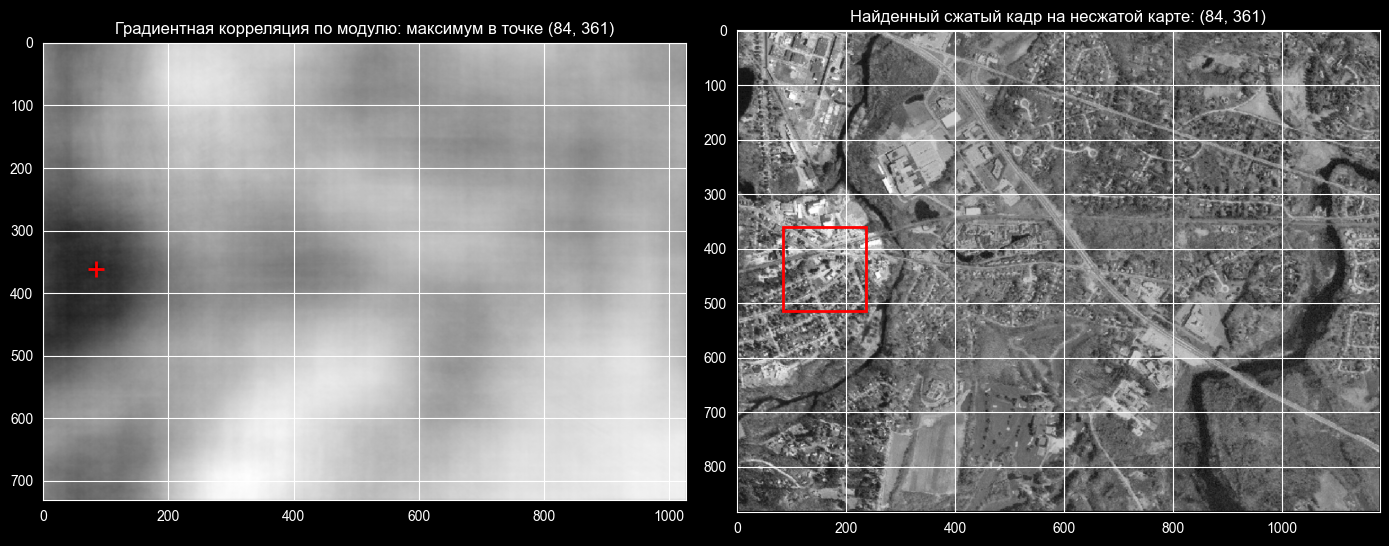

[Градиентная корреляция по компонентам]
Найден максимум: x = 84, y = 361, Rmax = 163884951.5974


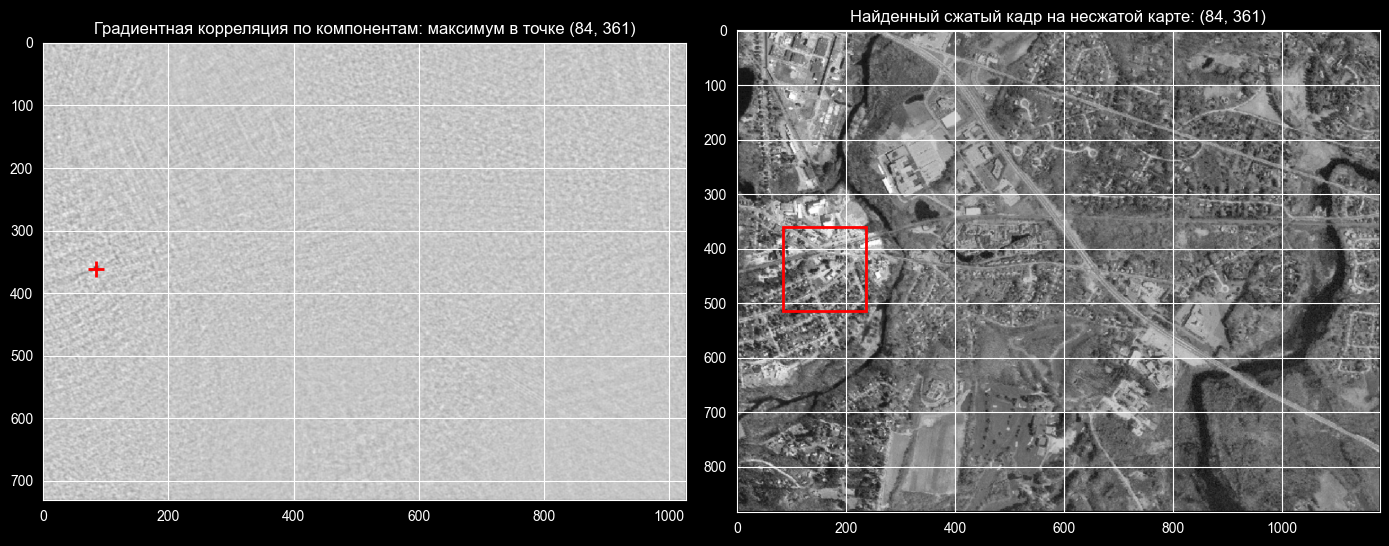

(np.int64(84), np.int64(361))

In [5]:
def GradCorr(A, B):
    """
    Градиентная корреляция по модулю градиента
    """
    h, w = A.shape
    Gax = cv2.Sobel(A, cv2.CV_64F, 1, 0, ksize=3)
    Gay = cv2.Sobel(A, cv2.CV_64F, 0, 1, ksize=3)
    Ga = np.sqrt(Gax ** 2 + Gay ** 2)
    Gbx = cv2.Sobel(B, cv2.CV_64F, 1, 0, ksize=3)
    Gby = cv2.Sobel(B, cv2.CV_64F, 0, 1, ksize=3)
    Gb = np.sqrt(Gbx ** 2 + Gby ** 2)
    Sa = np.fft.fft2(Ga)
    Sb = np.fft.fft2(Gb, s=(h, w))
    Sr = Sa * np.conj(Sb)
    R = np.fft.ifft2(Sr)
    return np.real(R)

R_grad = GradCorr(A, B_small)
show_result(A, B_small, R_grad, "Градиентная корреляция по модулю")

def GradCorrXY(A, B):
    """
    Градиентная корреляция по компонентам градиента
    """
    h, w = A.shape
    Gax = cv2.Sobel(A, cv2.CV_64F, 1, 0, ksize=3)
    Gay = cv2.Sobel(A, cv2.CV_64F, 0, 1, ksize=3)
    Gbx = cv2.Sobel(B, cv2.CV_64F, 1, 0, ksize=3)
    Gby = cv2.Sobel(B, cv2.CV_64F, 0, 1, ksize=3)
    Sr_x = np.fft.fft2(Gax) * np.conj(np.fft.fft2(Gbx, s=(h, w)))
    Sr_y = np.fft.fft2(Gay) * np.conj(np.fft.fft2(Gby, s=(h, w)))
    Sr = Sr_x + Sr_y
    R = np.fft.ifft2(Sr)
    return np.real(R)

R_grad_xy = GradCorrXY(A, B_small)
show_result(A, B_small, R_grad_xy, "Градиентная корреляция по компонентам")

5. Контурная корреляция.

[Контурная корреляция]
Найден максимум: x = 84, y = 361, Rmax = 4025.0000


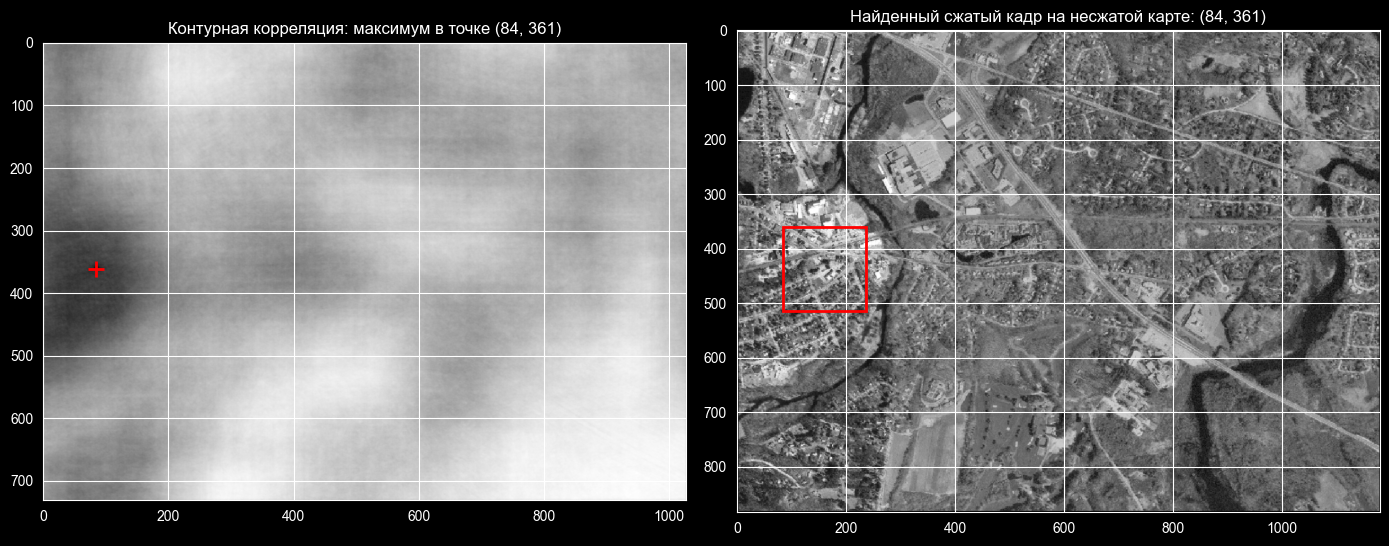

(np.int64(84), np.int64(361))

In [6]:
def edge_sobel(img):
    """
    Аналог MATLAB edge(img, 'Sobel')
    """
    img_u8 = np.clip(img, 0, 255).astype(np.uint8)
    gx = cv2.Sobel(img_u8, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_u8, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    mag = mag.astype(np.uint8)
    _, mask = cv2.threshold(
        mag,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return mask.astype(np.float64) / 255.0

def ContCorr(A, B):
    """
    Контурная корреляция
    """
    h, w = A.shape
    Ea = edge_sobel(A)
    Eb = edge_sobel(B)
    Sa = np.fft.fft2(Ea)
    Sb = np.fft.fft2(Eb, s=(h, w))
    Sr = Sa * np.conj(Sb)
    R = np.fft.ifft2(Sr)
    return np.real(R)

R_cont = ContCorr(A, B_small)
show_result(A, B_small, R_cont, "Контурная корреляция")

Сравнение методов (Шум, Поворот, Масштаб)

Правильное положение: x = 83, y = 360

Тест: Чувствительность к шуму


100%|██████████| 21/21 [00:15<00:00,  1.32it/s]



Тест: Чувствительность к повороту


100%|██████████| 21/21 [00:17<00:00,  1.21it/s]



Тест: Чувствительность к масштабу


100%|██████████| 21/21 [00:13<00:00,  1.55it/s]


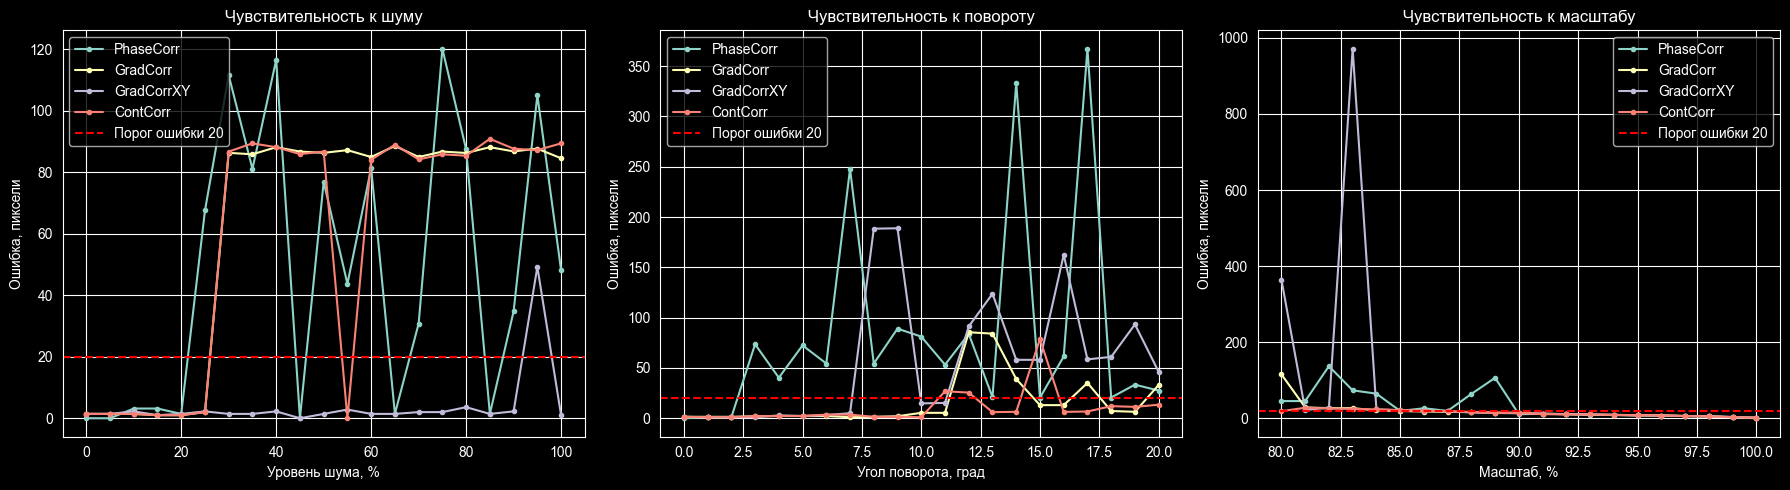

In [7]:
def add_salt_pepper(img, amount):
    """
    Шум salt & pepper
    """
    noisy = img.copy()
    h_img, w_img = noisy.shape
    num_salt = int(np.ceil(amount * h_img * w_img * 0.5))
    num_pepper = int(np.ceil(amount * h_img * w_img * 0.5))

    # Salt
    coords_y = np.random.randint(0, h_img, num_salt)
    coords_x = np.random.randint(0, w_img, num_salt)
    noisy[coords_y, coords_x] = 255

    # Pepper
    coords_y = np.random.randint(0, h_img, num_pepper)
    coords_x = np.random.randint(0, w_img, num_pepper)
    noisy[coords_y, coords_x] = 0
    return noisy

def apply_distortion(B_img, exp_type, value):
    """
    Применение искажений к кадру
    """
    if exp_type == 1:
        return add_salt_pepper(B_img, value / 100.0)
    elif exp_type == 2:
        return rotate(B_img, value, reshape=False, order=1)
    elif exp_type == 3:
        h_img, w_img = B_img.shape
        new_h = max(1, int(h_img * value / 100))
        new_w = max(1, int(w_img * value / 100))
        return cv2.resize(B_img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    else:
        return B_img

    # За правильное положение принимаем результат фазовой корреляции без искажений
R_ref = PhaseCorr(A, B_small)
h, w = A.shape
h1, w1 = B_small.shape

R_ref_valid = R_ref[:h - h1 + 1, :w - w1 + 1]
y_true, x_true = np.unravel_index(np.argmax(R_ref_valid), R_ref_valid.shape)
print(f"Правильное положение: x = {x_true}, y = {y_true}")

methods = {
    'PhaseCorr': PhaseCorr,
    'GradCorr': GradCorr,
    'GradCorrXY': GradCorrXY,
    'ContCorr': ContCorr
}

# Параметры экспериментов
N = np.arange(0, 105, 5)       # шум, %
Ang = np.arange(0, 21, 1)      # поворот, градусы
M = np.arange(100, 79, -1)     # масштаб, %

experiments = {
    1: {'data': N, 'title': 'Чувствительность к шуму', 'xlabel': 'Уровень шума, %'},
    2: {'data': Ang, 'title': 'Чувствительность к повороту', 'xlabel': 'Угол поворота, град'},
    3: {'data': M, 'title': 'Чувствительность к масштабу', 'xlabel': 'Масштаб, %'}
}

results = {
    exp_id: {method_name: [] for method_name in methods}
    for exp_id in experiments
}

for exp_id, params in experiments.items():
    print(f"\nТест: {params['title']}")
    for value in tqdm(params['data']):
        B_distorted = apply_distortion(B_small, exp_id, value)
        for method_name, method_func in methods.items():
            R = method_func(A, B_distorted)
            h_img, w_img = A.shape
            h_b, w_b = B_distorted.shape
            # Если кадр после искажений стал больше карты, пропускаем
            if h_b > h_img or w_b > w_img:
                err = 1000
            else:
                R_valid = R[:h_img - h_b + 1, :w_img - w_b + 1]
                y, x = np.unravel_index(np.argmax(R_valid), R_valid.shape)
                err = np.sqrt((x - x_true) ** 2 + (y - y_true) ** 2)
            results[exp_id][method_name].append(err)
        # print(f"  value = {value}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Ecrit = 20

for i, exp_id in enumerate(experiments):

    ax = axes[i]

    for method_name in methods:
        ax.plot(
            experiments[exp_id]['data'],
            results[exp_id][method_name],
            marker='.',
            label=method_name
        )

    ax.axhline(Ecrit, color='r', linestyle='--', label='Порог ошибки 20')

    ax.set_title(experiments[exp_id]['title'])
    ax.set_xlabel(experiments[exp_id]['xlabel'])
    ax.set_ylabel('Ошибка, пиксели')

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()